# Analyse exploratoire — Agriculture CropYield

**Objectif** : comprendre le fichier `crop_yield.csv` avant de le préparer : colonnes, types,
qualité des données et variables liées au rendement.

**Données** : `data/agriculture-crop-yield/crop_yield.csv`. Une ligne = **une parcelle sur une saison**.

| Colonne | Type | Description |
|---|---|---|
| `Region` | texte | Zone : North, East, South, West |
| `Soil_Type` | texte | Type de sol : Sandy, Clay, Loam, Silt, Peaty, Chalky |
| `Crop` | texte | Culture : Wheat, Rice, Maize, Barley, Soybean, Cotton |
| `Rainfall_mm` | décimal | Pluie sur la saison, en mm |
| `Temperature_Celsius` | décimal | Température moyenne, en °C |
| `Fertilizer_Used` | booléen | Engrais utilisé ou non |
| `Irrigation_Used` | booléen | Irrigation utilisée ou non |
| `Weather_Condition` | texte | Météo dominante : Sunny, Rainy, Cloudy |
| `Days_to_Harvest` | entier | Nombre de jours avant la récolte |
| `Yield_tons_per_hectare` | décimal | **Cible** : rendement en tonnes par hectare |

Exemple avec la première ligne : une parcelle de l'Ouest, sol sableux, cultivée en coton, avec
897 mm de pluie, 27,7 °C, sans engrais mais avec irrigation, temps nuageux, récoltée après
122 jours. Rendement : 6,56 t/ha.

# Imports

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from agritech import profile, utils
from agritech.config import AGRICULTURE_CROP_YIELD_FILENAME, PATHS

# Lecture du dataset

In [2]:
csv_path = PATHS.data_agriculture_crop_yield / AGRICULTURE_CROP_YIELD_FILENAME

In [3]:
df = pd.read_csv(csv_path)
df

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251
...,...,...,...,...,...,...,...,...,...,...
999995,West,Silt,Rice,302.805345,27.987428,False,False,Sunny,76,1.347586
999996,South,Chalky,Barley,932.991383,39.661039,True,False,Rainy,93,7.311594
999997,North,Peaty,Cotton,867.362046,24.370042,True,False,Cloudy,108,5.763182
999998,West,Silt,Wheat,492.812857,33.045505,False,False,Sunny,102,2.070159


# Vue d'ensemble

In [4]:
p_crop_yield = profile.profile_report(df, PATHS.docs / "eda_crop_yield_rapport.html")

Observations       : 1,000,000
Variables          : 10
Cellules manquantes: 0 (0.00%)
Lignes dupliquees  : 0 (0.00%)
Taille en memoire  : 62.9 Mo
Types              : {'Text': 4, 'Numeric': 4, 'Boolean': 2}

Alertes :
 - [Rainfall_mm] is highly overall correlated with [Yield_tons_per_hectare]
 - [Yield_tons_per_hectare] is highly overall correlated with [Rainfall_mm]
 - [Rainfall_mm] has unique values
 - [Temperature_Celsius] has unique values
 - [Yield_tons_per_hectare] has unique values


In [5]:
desc = p_crop_yield.get_description()
pd.DataFrame(desc.variables).T[["type", "n_distinct", "p_missing", "mean", "std", "min", "max"]].sort_values("type")

,type,n_distinct,p_missing,mean,std,min,max
Fertilizer_Used,Boolean,2,0.0,NaN,NaN,NaN,NaN
Irrigation_Used,Boolean,2,0.0,NaN,NaN,NaN,NaN
Rainfall_mm,Numeric,1000000,0.0,549.981901,259.85132,100.000896,999.998098
Temperature_Celsius,Numeric,1000000,0.0,27.504965,7.220608,15.000034,39.999997
Days_to_Harvest,Numeric,90,0.0,104.495025,25.953412,60,149
Yield_tons_per_hectare,Numeric,1000000,0.0,4.649472,1.696572,-1.147613,9.963372
Region,Text,4,0.0,NaN,NaN,NaN,NaN
Soil_Type,Text,6,0.0,NaN,NaN,NaN,NaN
Crop,Text,6,0.0,NaN,NaN,NaN,NaN
Weather_Condition,Text,3,0.0,NaN,NaN,NaN,NaN


**Observations :**

- 1 000 000 lignes et 10 colonnes, sans valeur manquante ni doublon.
- Types corrects : 4 colonnes texte, 4 numériques, 2 booléennes.
- Seule alerte utile du profiling : la forte corrélation entre la pluie et le rendement.

# Variables numériques

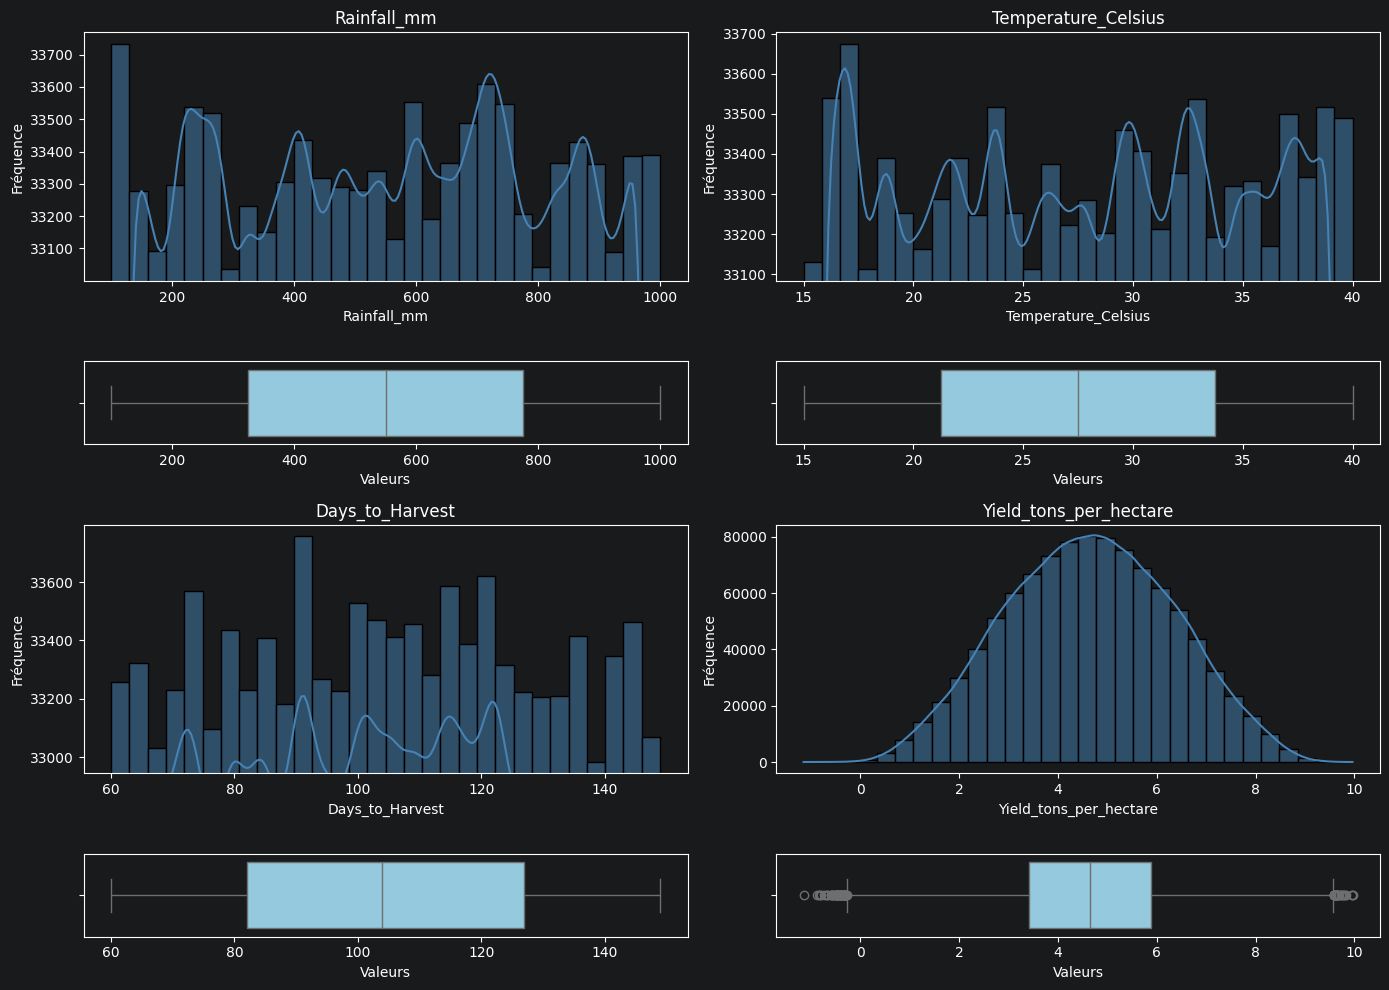

In [6]:
num_cols = ["Rainfall_mm", "Temperature_Celsius", "Days_to_Harvest", "Yield_tons_per_hectare"]
utils.plot_distribs(df, num_cols)

**Observations :**

- Pluie, température et `Days_to_Harvest` ont une distribution uniforme.
- Le rendement suit une courbe en cloche centrée sur 4,65 t/ha, sans forte asymétrie.
- Attention : l'axe vertical ne part pas de zéro, les creux visibles ne font que 2 % d'écart.

## Valeurs atypiques

In [7]:
# Valeur atypique : en dehors de [Q1 - 1,5 × IQR ; Q3 + 1,5 × IQR]
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    basse, haute = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = ((df[col] < basse) | (df[col] > haute)).sum()
    print(f"{col:24} {n:6d} atypiques ({n / len(df):.3%})   bornes = [{basse:.2f}, {haute:.2f}]")

Rainfall_mm                   0 atypiques (0.000%)   bornes = [-349.88, 1449.51]
Temperature_Celsius           0 atypiques (0.000%)   bornes = [2.51, 52.50]
Days_to_Harvest               0 atypiques (0.000%)   bornes = [14.50, 194.50]
Yield_tons_per_hectare       84 atypiques (0.008%)   bornes = [-0.27, 9.57]


**Observations :**

- Aucune valeur atypique pour la pluie, la température et `Days_to_Harvest`.
- Rendement : 84 valeurs atypiques (0,008 %), sous −0,27 ou au-dessus de 9,57 t/ha.
- Rien n'est supprimé ici ; les rendements négatifs sont regardés juste après.

### Cible

In [8]:
df['Yield_tons_per_hectare'].describe()

count    1000000.000000
mean           4.649472
std            1.696572
min           -1.147613
25%            3.417637
50%            4.651808
75%            5.879200
max            9.963372
Name: Yield_tons_per_hectare, dtype: float64

Conditions de culture des rendements négatifs :

In [9]:
negative_target = df[df['Yield_tons_per_hectare'] < 0]
print("Nombre de rendements négatifs : ", len(negative_target))
print("   -> Fertilizer_Used ? ", len(negative_target[negative_target['Fertilizer_Used'] == True]))
print("   -> Irrigation_Used ? ", len(negative_target[negative_target['Irrigation_Used'] == True]))

print("   -> Pluie ? ")
print("      - < 200 : ",len(negative_target[negative_target['Rainfall_mm'] < 200]))
print("      - > 200 : ",len(negative_target[negative_target['Rainfall_mm'] > 200]))
print(f"     - (min,max) : ({min(negative_target['Rainfall_mm']):3.2f},{max(negative_target['Rainfall_mm']):3.2f})")

print("   -> Température ? ")
print("      - < 20 : ",len(negative_target[negative_target['Temperature_Celsius'] < 20]))
print("      - > 20 : ",len(negative_target[negative_target['Temperature_Celsius'] > 20]))
print(f"     - (min,max) : ({min(negative_target['Temperature_Celsius']):3.2f},{max(negative_target['Temperature_Celsius']):3.2f})")
negative_target

Nombre de rendements négatifs :  231
   -> Fertilizer_Used ?  0
   -> Irrigation_Used ?  0
   -> Pluie ? 
      - < 200 :  223
      - > 200 :  8
     - (min,max) : (100.30,235.79)
   -> Température ? 
      - < 20 :  101
      - > 20 :  130
     - (min,max) : (15.05,39.79)


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
756,East,Peaty,Cotton,101.019421,33.804131,False,False,Rainy,117,-0.007103
7799,South,Chalky,Rice,108.804894,18.004082,False,False,Sunny,86,-0.061283
8421,East,Chalky,Soybean,168.120735,38.473430,False,False,Cloudy,111,-0.119911
9553,North,Silt,Wheat,156.607973,16.610257,False,False,Sunny,129,-0.193093
15435,South,Chalky,Maize,177.481344,27.719742,False,False,Sunny,94,-0.009811
...,...,...,...,...,...,...,...,...,...,...
975666,South,Clay,Barley,116.114046,16.257818,False,False,Sunny,70,-0.471038
982738,West,Loam,Wheat,235.792353,31.699429,False,False,Sunny,68,-0.255772
987054,West,Peaty,Barley,100.467398,15.735951,False,False,Rainy,96,-0.120282
995837,East,Chalky,Maize,105.575189,15.864764,False,False,Rainy,111,-0.051633


In [10]:
negative_target[negative_target['Rainfall_mm'] > 200]

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
79075,East,Sandy,Soybean,204.482096,31.138692,False,False,Rainy,112,-0.059135
108927,North,Chalky,Rice,210.628152,26.307165,False,False,Cloudy,97,-0.082906
245998,South,Peaty,Soybean,224.789788,25.041274,False,False,Cloudy,79,-0.097219
738667,North,Silt,Barley,223.337914,17.702795,False,False,Sunny,119,-0.171990
772276,West,Sandy,Rice,213.305355,29.258801,False,False,Rainy,102,-0.063215
803418,West,Clay,Rice,219.983518,17.346570,False,False,Sunny,117,-0.179330
863301,South,Chalky,Maize,223.302364,27.363624,False,False,Cloudy,127,-0.190826
982738,West,Loam,Wheat,235.792353,31.699429,False,False,Sunny,68,-0.255772


**Observations :**

- Le rendement va de −1,15 à 9,96 t/ha, avec une moyenne et une médiane de 4,65.
- 231 rendements sont négatifs (0,023 %) : tous sans engrais ni irrigation, dont 223 avec moins
  de 200 mm de pluie.
- Un rendement négatif est impossible : ces lignes sont exclues du dataset d’entraînement de /predict (notebook 06). Elles pourront être conservées à part pour examiner les prédictions du modèle après entraînement, sans les utiliser pour évaluer ses performances.

### Corrélations

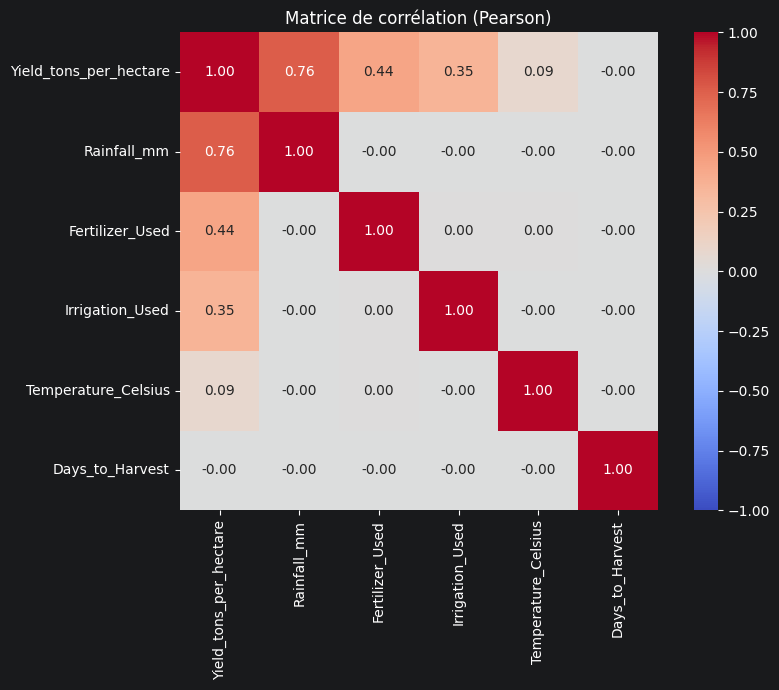

In [11]:
# Corrélations de Pearson, triées selon le lien avec le rendement
utils.plot_pearson_matrix(df, target="Yield_tons_per_hectare")

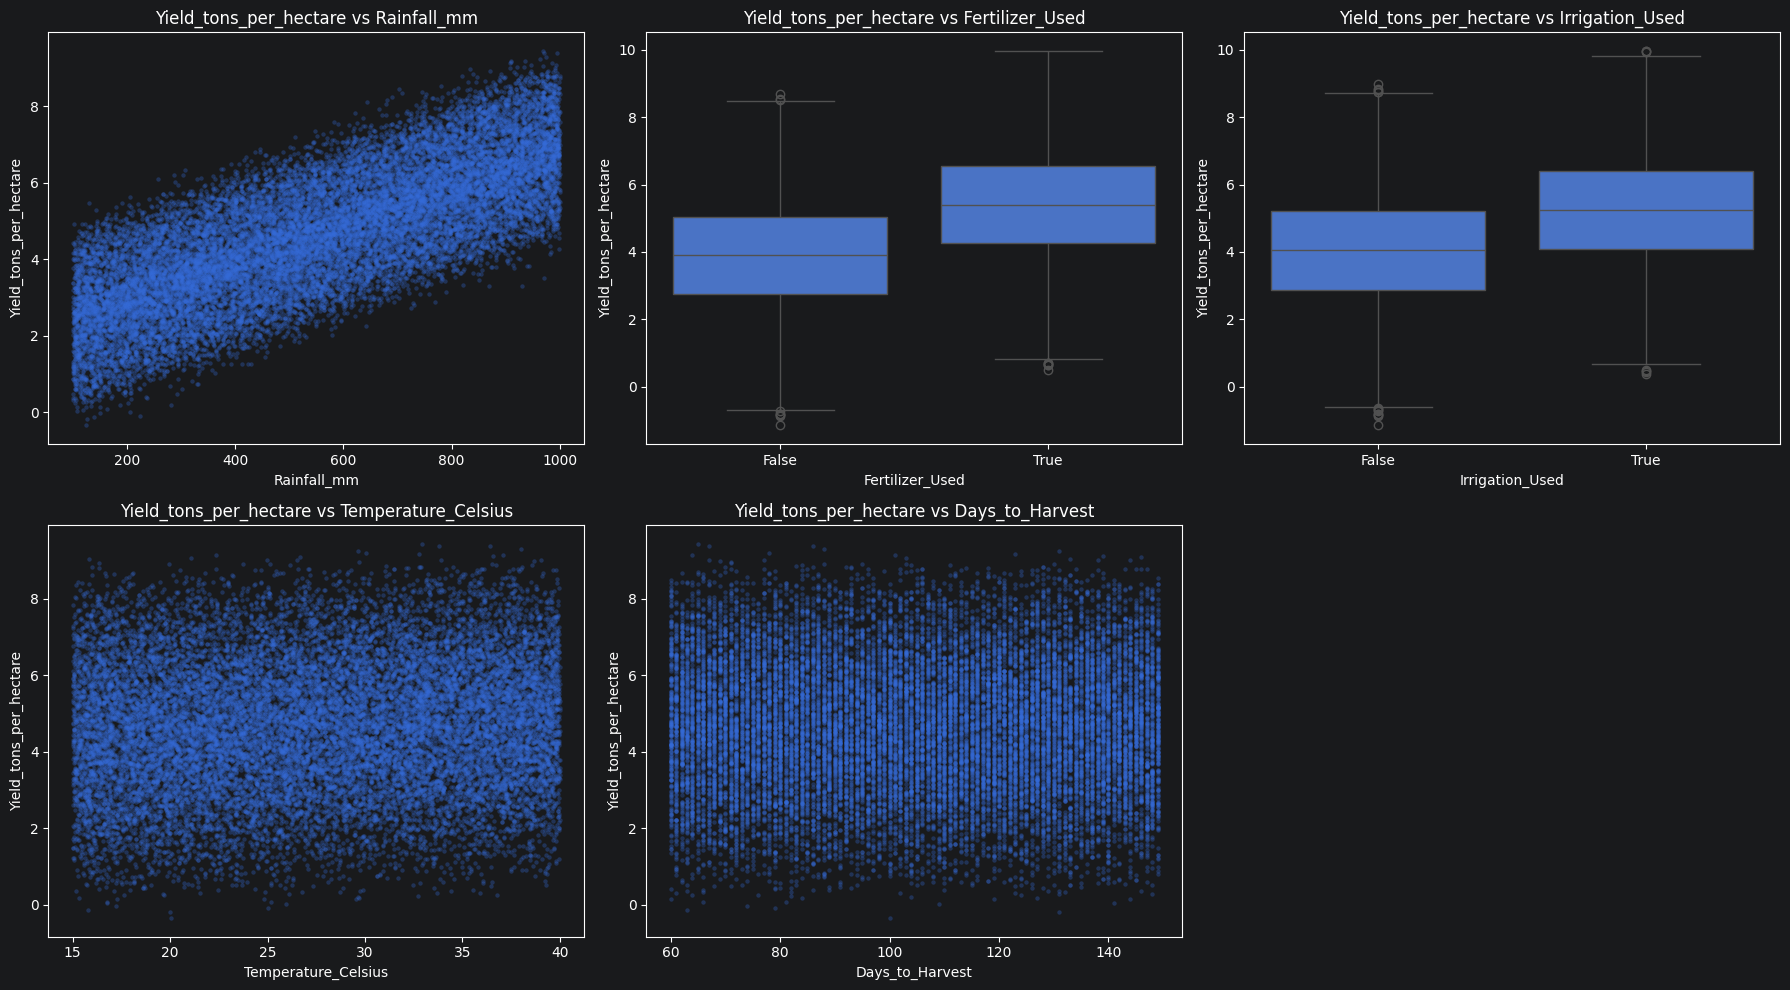

In [12]:
# Croisements avec la cible pour les variables les plus corrélées
utils.plot_pairs(
    df,
    "Yield_tons_per_hectare",
    ["Rainfall_mm", "Fertilizer_Used", "Irrigation_Used", "Temperature_Celsius", "Days_to_Harvest"],
)

**Observations :**

- Corrélation avec le rendement : pluie 0,76, engrais 0,44, irrigation 0,35, température 0,09,
  `Days_to_Harvest` 0,00.
- Les variables d'entrée ne sont pas corrélées entre elles.
- En moyenne, l'engrais apporte +1,50 t/ha et l'irrigation +1,20 t/ha ; la relation entre pluie et
  rendement est linéaire.

### Température

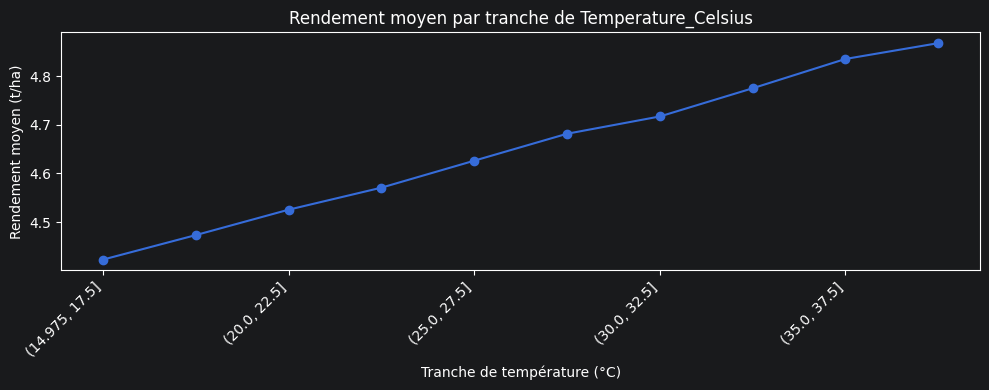

écart entre la tranche la plus froide et la plus chaude : +0.445 t/ha


In [13]:
# Corrélation faible (0,09) : le rendement moyen change-t-il quand même avec la température ?
utils.use_inline_backend()

tranches_temp = pd.cut(df["Temperature_Celsius"], bins=10)
moyennes_temp = df.groupby(tranches_temp, observed=True)["Yield_tons_per_hectare"].mean()

ax = moyennes_temp.plot(marker="o", figsize=(10, 4))
ax.set_xlabel("Tranche de température (°C)")
ax.set_ylabel("Rendement moyen (t/ha)")
ax.set_title("Rendement moyen par tranche de Temperature_Celsius")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

ecart = moyennes_temp.iloc[-1] - moyennes_temp.iloc[0]
print(f"écart entre la tranche la plus froide et la plus chaude : {ecart:+.3f} t/ha")

**Observations :**

- Le rendement moyen augmente régulièrement des tranches les plus froides aux plus chaudes :
  +0,445 t/ha.
- L'effet est faible mais régulier : une corrélation faible ne veut pas dire que la variable est
  inutile.

### Days_to_Harvest

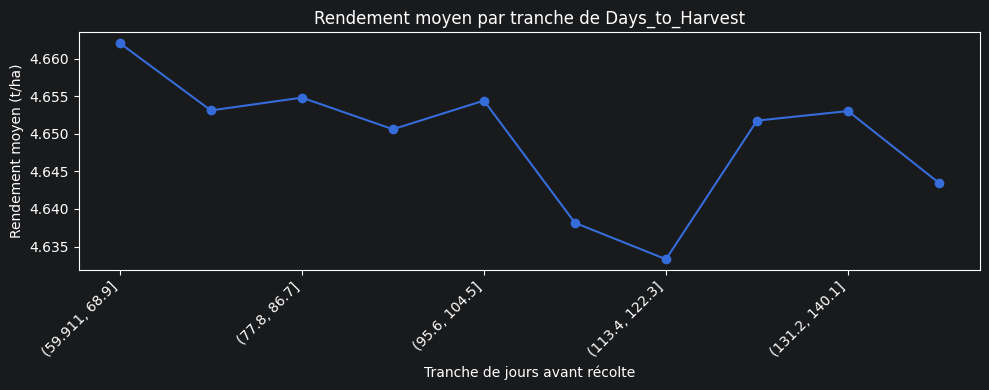

amplitude entre tranches : 0.0288 t/ha


In [14]:
# La corrélation ne détecte que les relations linéaires : on regarde aussi le rendement moyen par tranche.
utils.use_inline_backend()

tranches = pd.cut(df["Days_to_Harvest"], bins=10)
moyennes = df.groupby(tranches, observed=True)["Yield_tons_per_hectare"].mean()

ax = moyennes.plot(marker="o", figsize=(10, 4))
ax.set_xlabel("Tranche de jours avant récolte")
ax.set_ylabel("Rendement moyen (t/ha)")
ax.set_title("Rendement moyen par tranche de Days_to_Harvest")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"amplitude entre tranches : {moyennes.max() - moyennes.min():.4f} t/ha")

**Observations :**

- Le rendement moyen varie de 0,029 t/ha seulement d'une tranche à l'autre, sans tendance.
- Aucune relation, ni linéaire ni en courbe.

## Interactions simples

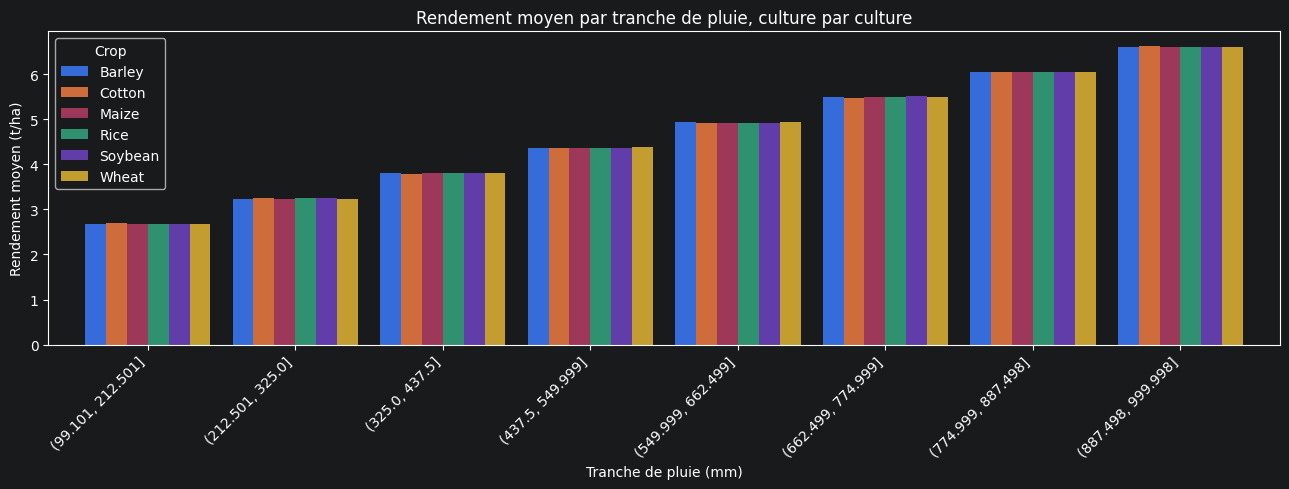

écart maximum entre cultures, à pluie comparable : 0.0280 t/ha


In [15]:
# La relation pluie -> rendement est-elle la même pour toutes les cultures ?
utils.use_inline_backend()

tranches_pluie = pd.cut(df["Rainfall_mm"], bins=8)
par_culture = df.pivot_table(
    index=tranches_pluie, columns="Crop",
    values="Yield_tons_per_hectare", aggfunc="mean", observed=True,
)

ax = par_culture.plot(kind="bar", figsize=(13, 5), width=0.85)
ax.set_xlabel("Tranche de pluie (mm)")
ax.set_ylabel("Rendement moyen (t/ha)")
ax.set_title("Rendement moyen par tranche de pluie, culture par culture")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

ecarts = par_culture.max(axis=1) - par_culture.min(axis=1)
print(f"écart maximum entre cultures, à pluie comparable : {ecarts.max():.4f} t/ha")

In [16]:
# L'effet de l'engrais et de l'irrigation est-il le même pour toutes les cultures ?
for variable in ["Fertilizer_Used", "Irrigation_Used"]:
    table = df.pivot_table(index="Crop", columns=variable, values="Yield_tons_per_hectare")
    table["ecart"] = table[True] - table[False]
    print(f"-- {variable}")
    print(table.round(3).to_string())
    print(f"   variation de l'écart entre cultures : "
          f"{table['ecart'].max() - table['ecart'].min():.4f} t/ha\n")

-- Fertilizer_Used
Fertilizer_Used  False   True  ecart
Crop                                
Barley           3.891  5.406  1.514
Cotton           3.902  5.398  1.495
Maize            3.897  5.391  1.494
Rice             3.900  5.401  1.501
Soybean          3.906  5.402  1.495
Wheat            3.901  5.402  1.501
   variation de l'écart entre cultures : 0.0205 t/ha

-- Irrigation_Used
Irrigation_Used  False   True  ecart
Crop                                
Barley           4.051  5.245  1.194
Cotton           4.052  5.251  1.198
Maize            4.038  5.245  1.206
Rice             4.052  5.258  1.205
Soybean          4.048  5.257  1.209
Wheat            4.057  5.246  1.189
   variation de l'écart entre cultures : 0.0201 t/ha



**Observations :**

- À pluie comparable, les 6 cultures ont presque le même rendement : 0,028 t/ha d'écart au maximum.
- L'effet de l'engrais et de l'irrigation varie de 0,02 t/ha seulement d'une culture à l'autre.
- Rien ne permet de classer les cultures avec ce dataset : c'est un point important pour
  `/recommend`.

## Variables booléennes

In [17]:
for col in ["Fertilizer_Used", "Irrigation_Used"]:
    print(df[col].value_counts(normalize=True).to_string(), "\n")

Fertilizer_Used
False    0.50006
True     0.49994 

Irrigation_Used
False    0.500509
True     0.499491 



**Observations :**

- Engrais et irrigation : environ 50 % de oui et 50 % de non.
- Les 4 combinaisons engrais / irrigation comptent chacune environ 250 000 lignes.

## Variables catégorielles

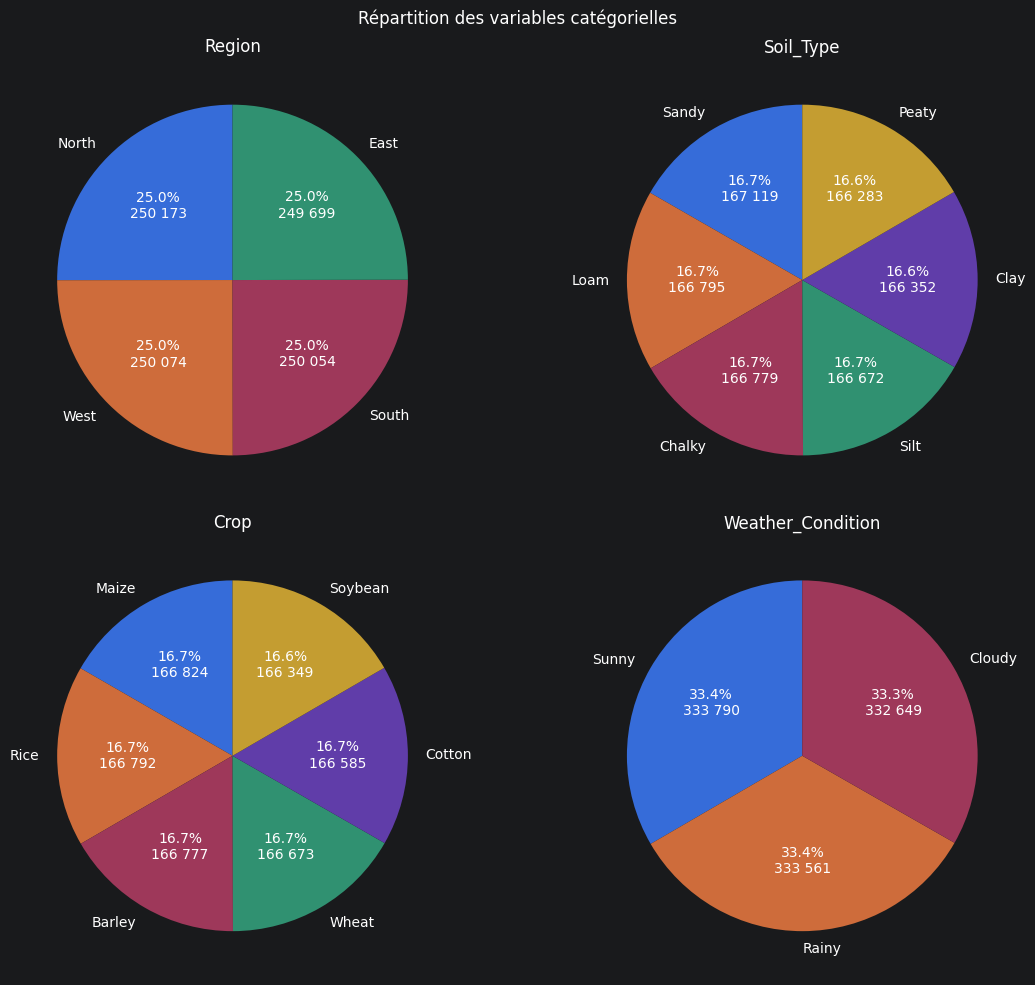

In [18]:
cat_cols = ["Region", "Soil_Type", "Crop", "Weather_Condition"]
utils.plot_pies(df, cat_cols)

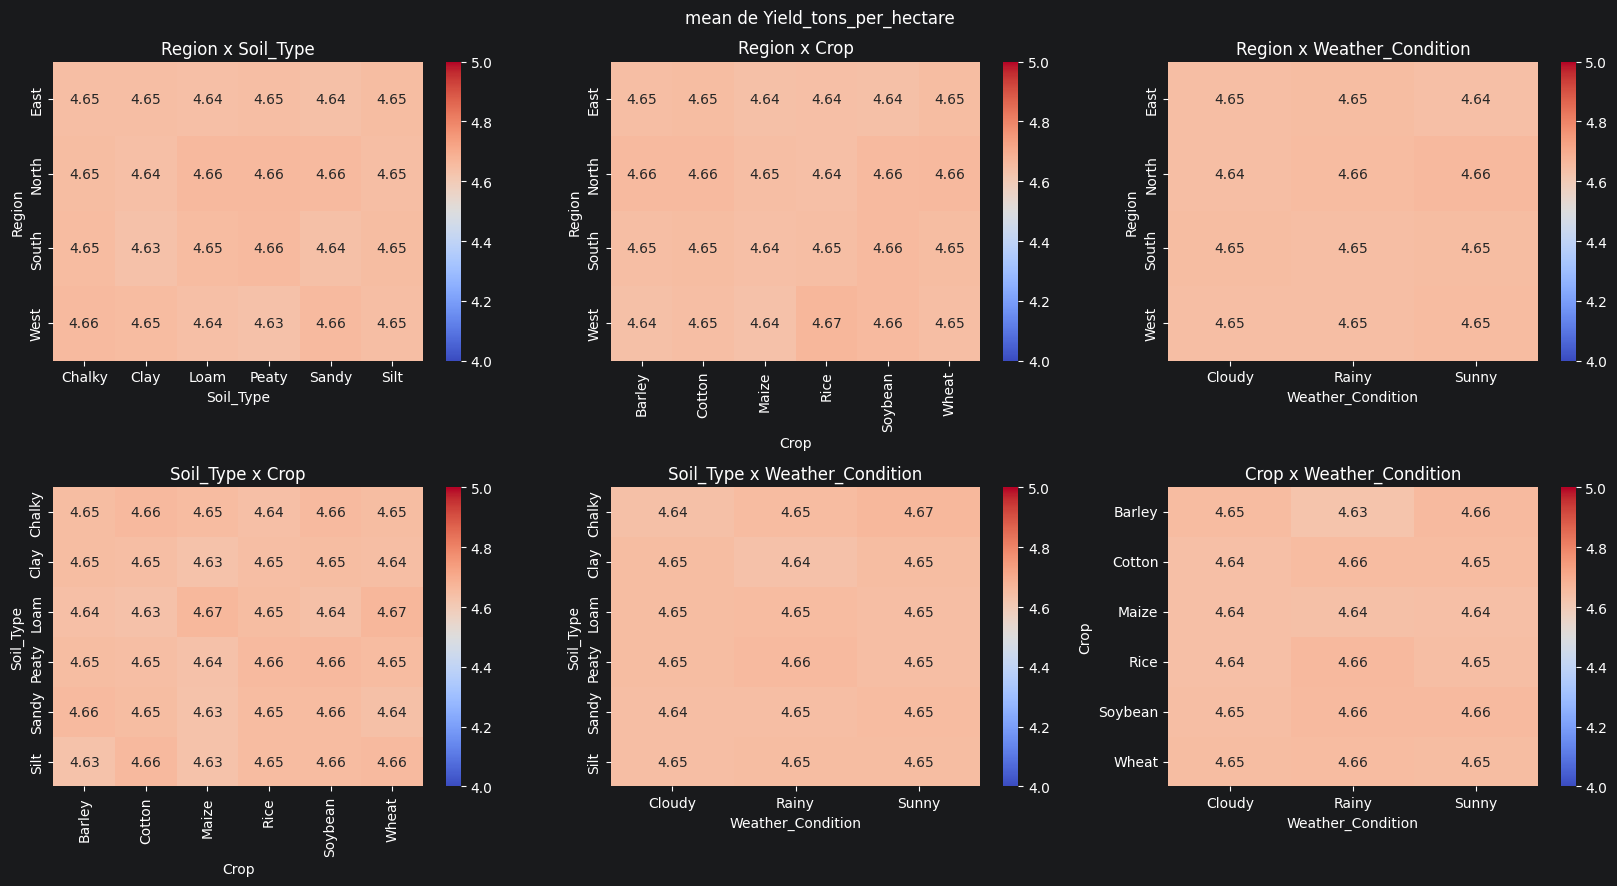

In [19]:
# Rendement moyen pour chaque croisement de variables catégorielles
utils.plot_cat_heatmaps(df, "Yield_tons_per_hectare", cat_cols, vmin=4, vmax=5)

In [20]:
# Écart de rendement moyen entre les modalités de chaque variable
for col in cat_cols:
    moyennes = df.groupby(col)["Yield_tons_per_hectare"].mean()
    print(f"{col:18} écart max entre modalités : {moyennes.max() - moyennes.min():.4f} t/ha")

Region             écart max entre modalités : 0.0085 t/ha
Soil_Type          écart max entre modalités : 0.0080 t/ha
Crop               écart max entre modalités : 0.0123 t/ha
Weather_Condition  écart max entre modalités : 0.0047 t/ha


**Observations :**

- Les 4 variables texte sont équilibrées : 25 % par région, 16,7 % par culture et par sol, 33,3 %
  par météo.
- Le rendement moyen varie de 0,012 t/ha au maximum entre les modalités d'une même variable :
  aucune différence notable.
- Avec une échelle commune de 4 à 5 t/ha, les écarts de rendement moyen restent faibles.

## Cohérence des données

In [21]:
# La météo déclarée est-elle liée à la pluie et à la température mesurées ?
print(df.groupby("Weather_Condition")["Rainfall_mm"].agg(["mean", "min", "max"]).round(1), "\n")
print(df.groupby("Weather_Condition")["Temperature_Celsius"].mean().round(2))

                    mean    min     max
Weather_Condition                      
Cloudy             549.5  100.0  1000.0
Rainy              550.1  100.0  1000.0
Sunny              550.3  100.0  1000.0 

Weather_Condition
Cloudy    27.52
Rainy     27.49
Sunny     27.50
Name: Temperature_Celsius, dtype: float64


**Observations :**

- La pluie moyenne (549,5 à 550,3 mm) et la température moyenne (27,5 °C) sont les mêmes quelle
  que soit la météo déclarée.
- `Weather_Condition` n'est donc pas liée à la pluie ni à la température mesurées.

# Conclusion

- **Données** : 1 000 000 lignes, 10 colonnes, sans valeur manquante ni doublon.
- **Associations observées** : pluie (corrélation 0,76), engrais (+1,50 t/ha en moyenne) et
  irrigation (+1,20 t/ha en moyenne), sans preuve de causalité.
- **Température** : le rendement moyen augmente de 0,445 t/ha entre les tranches extrêmes.
- **Peu de différences visibles** : `Region`, `Soil_Type`, `Crop`, `Weather_Condition` et
  `Days_to_Harvest`. Les 6 cultures ont des rendements moyens très proches dans les comparaisons réalisées.
- **Qualité** : 231 rendements négatifs, tous sans engrais ni irrigation.